<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/Cross%20Lagged.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga y normalización

In [1]:
!wget https://www.latinobarometro.org/documents/LAT-2024/latinobarometro-2024-stata-v20250817.zip
!unzip latinobarometro-2024-stata-v20250817.zip

!wget https://www.latinobarometro.org/documents/LAT-2023/latinobarometro-2023-stata-v1-0.zip
!unzip latinobarometro-2023-stata-v1-0.zip

!wget https://www.latinobarometro.org/documents/LAT-2020/latinobarometro-2020-esp-stata-v1-0.zip
!unzip latinobarometro-2020-esp-stata-v1-0.zip

--2026-05-07 13:53:44--  https://www.latinobarometro.org/documents/LAT-2024/latinobarometro-2024-stata-v20250817.zip
Resolving www.latinobarometro.org (www.latinobarometro.org)... 80.28.53.190
Connecting to www.latinobarometro.org (www.latinobarometro.org)|80.28.53.190|:443... connected.
HTTP request sent, awaiting response... 200 200
Length: 6691592 (6.4M) [application/x-zip-compressed]
Saving to: ‘latinobarometro-2024-stata-v20250817.zip’

latinobarometro-202 100%[===================>]   6.38M  7.11MB/s    in 0.9s    

2026-05-07 13:53:46 (7.11 MB/s) - ‘latinobarometro-2024-stata-v20250817.zip’ saved [6691592/6691592]

Archive:  latinobarometro-2024-stata-v20250817.zip
  inflating: Latinobarometro_2024_Stata_eng_v20250817.dta  
  inflating: Latinobarometro_2024_Stata_esp_v20250817.dta  
  inflating: Latinobarometro_2024_Cuestionario_esp.pdf  
  inflating: Latinobarometro_2024_Cuestionario_eng.pdf  
--2026-05-07 13:53:47--  https://www.latinobarometro.org/documents/LAT-2023/latinobaro

In [2]:
import pandas as pd
import numpy as np

# 1) Cargar archivos (sin convertir value labels)
df20 = pd.read_stata("Latinobarometro_2020_Esp_Stata_v1_0.dta", convert_categoricals=False)
df23 = pd.read_stata("Latinobarometro_2023_Esp_Stata_v1_0.dta", convert_categoricals=False)
df24 = pd.read_stata("Latinobarometro_2024_Stata_esp_v20250817.dta", convert_categoricals=False)

# 2) detectar id y crear id,wave
def detect_id(df):
    for c in ["IDNUM","idnum","Idnum","id_num","NUMINVES","numinves"]:
        if c in df.columns:
            return c
    raise ValueError("No se encontró ID en la base.")
df20["id"] = df20[detect_id(df20)].astype(int)
df23["id"] = df23[detect_id(df23)].astype(int)
df24["id"] = df24[detect_id(df24)].astype(int)
df20["wave"] = 2020
df23["wave"] = 2023
df24["wave"] = 2024

/tmp/ipykernel_10016/3825057927.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df24["id"] = df24[detect_id(df24)].astype(int)
/tmp/ipykernel_10016/3825057927.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df24["wave"] = 2024


In [3]:
# 3) mapping confirmado (usaste/confirmaste estos nombres)
mapping_2020 = {
    "p1st": "felicidad",
    "p46stgbs": "interes_politica",
    "p49stgbs": "identificacion_partidaria",
    "p18st": "polarizacion_continua",
    "p62st_d": "polarizacion_economia",
    "p20st_a": "democratico",
    "p22stm_b": "nodemocratico",
    "p9stgbs": "confianza",
    "s4": "econ_personal",
    "p4stgbs": "econ_pais",
    "edad": "edad",
    "s16": "educacion",
    "sexo": "genero",
    "idenpa": "pais",
    "ciudad": "ciudad",
    "p60n_c": "protestas"
}
mapping_2023 = {
    "P1ST": "felicidad",
    "P40STGBS": "interes_politica",
    "P42STGBS": "identificacion_partidaria",
    "P16ST": "polarizacion_continua",
    "P54ST_B": "polarizacion_economia",
    "P18ST_A": "democratico",
    "P18STM_B": "nodemocratico",
    "P9STGBS": "confianza",
    "S4": "econ_personal",
    "P4STGBS": "econ_pais",
    "edad": "edad",
    "S11": "educacion",
    "sexo": "genero",
    "idenpa": "pais",
    "ciudad": "ciudad",
    "P50ST": "protestas"
}
mapping_2024 = {
    "P1ST": "felicidad",
    "P36STGBS": "interes_politica",
    "P26ST": "eficacia_voto",
    "P25ST": "representacion",
    "P16ST": "polarizacion_continua",
    "P33ST.D": "polarizacion_economia",
    "P38STGBS": "identificacion_partidaria",
    "P18ST.A": "democratico",
    "P18ST.B": "nodemocratico",
    "P18ST.C": "porencima",
    "P10STGBS": "confianza",
    "S4": "econ_personal",
    "P4ST": "econ_pais",
    "EDAD": "edad",
    "S11": "educacion",
    "SEXO": "genero",
    "IDENPA": "pais",
    "CIUDAD": "ciudad",
    "P44ST": "protestas"
}

def apply_mapping(df, mp):
    df2 = df.copy()
    not_found = []
    for raw, std in mp.items():
        if raw in df2.columns:
            df2[std] = df2[raw]
        else:
            not_found.append(raw)
    return df2, not_found

df20r, miss20 = apply_mapping(df20, mapping_2020)
df23r, miss23 = apply_mapping(df23, mapping_2023)
df24r, miss24 = apply_mapping(df24, mapping_2024)

if miss20: print("⚠️ Missing mapping 2020:", miss20)
if miss23: print("⚠️ Missing mapping 2023:", miss23)
if miss24: print("⚠️ Missing mapping 2024:", miss24)

# 4) Variables estándar a mantener (si faltan quedan NaN)
vars_std = [
    "felicidad","interes_politica","eficacia_voto","representacion", "polarizacion_economia",
    "polarizacion_continua","identificacion_partidaria","democratico","nodemocratico",
    "confianza","econ_personal","econ_pais","edad","educacion","genero", "pais", "protestas", "ciudad"
]

def safe_slice(df, cols):
    df2 = df.copy()
    for c in cols:
        if c not in df2.columns:
            df2[c] = np.nan
    return df2[["id","wave"] + cols]

df20s = safe_slice(df20r, vars_std)
df23s = safe_slice(df23r, vars_std)
df24s = safe_slice(df24r, vars_std)

df_long = pd.concat([df20s, df23s, df24s], ignore_index=True)
print("df_long shape:", df_long.shape)

df_long shape: (58623, 20)


In [4]:
# 1) Conversión explícita (idéntica a 2024)
conversion = {
    "derecha": 10,
    "izquierda": 0,
    "Ninguno": np.nan,
    "No contesta": np.nan,
    "No sabe": np.nan,
    97: np.nan,
    99: np.nan,
    "97": np.nan,
    "99": np.nan
}

def convertir(val):
    if val in conversion:
        return conversion[val]
    try:
        num = float(val)
        if num in [97, 99]:
            return np.nan
        return num
    except:
        return np.nan

# 2) Aplicar conversión solo donde existe escala ideológica
df_long["escala_lr"] = df_long["polarizacion_continua"].apply(convertir)

# 3) Distancia al centro (0–5), idéntica a 2024
df_long["polarizacion_continua"] = np.abs(df_long["escala_lr"] - 5)

# 4) Limpieza
df_long = df_long.drop(columns="escala_lr")

In [5]:
conversion = {
    3: 2,  # No muy satisfecho
    4: 1,  # Para nada satisfecho
    2: 3,  # Bastante satisfecho
    1: 4   # Muy satisfecho
}


# Reemplazar valores en la columna P1ST
df_long["felicidad"] = df_long["felicidad"].map(conversion)

# Interés en la política (1=Muy interesado ... 4=Nada interesado) → invertimos para que valores altos = más interés
df_long["interes_politica"] = df_long["interes_politica"].replace({1:4, 2:3, 3:2, 4:1})

# Sentimiento partidario (1=Sí, 2=No)
df_long["identificacion_partidaria"] = df_long["identificacion_partidaria"].replace({1:1, 2:0})

# Polarizacion económica
df_long["polarizacion_economia"] = df_long["polarizacion_economia"].replace({1:1, 2:0, 3:0, 4:1})

# Representación política (1=Sí, 2=No)
df_long["representacion"] = df_long["representacion"].replace({1:1, 2:0})

# Eficacia política (P26ST: 1=cree que su voto hace diferencia, 2=no)
df_long["eficacia_voto"] = df_long["eficacia_voto"].replace({1:1, 2:0})

In [6]:
# === 2. Conversiones ===
##################################################################
# Edad: asegurar numérico
df_long["edad"] = pd.to_numeric(df_long["edad"], errors="coerce")

##################################################################
# Género: 1 = hombre, 2 = mujer → 0/1
df_long["genero"] = df_long["genero"].replace({1: 0, 2: 1})

##################################################################
# Educación: usar S16 (1 = sin estudios ... 14 = universidad)
# Paso 1: convertir a numérico
df_long["educacion_num"] = pd.to_numeric(df_long["educacion"], errors="coerce")

# Paso 2: definir el escalador manual
def escalar_educacion(x):
    if pd.isna(x):
        return np.nan
    if x == 1:
        return 0  # sin estudios
    elif 2 <= x <= 13:
        return x - 1  # años reales (1–12)
    elif x == 14:  # universitario incompleto
        return 14
    elif x == 15:  # universitario completo
        return 16
    elif x == 16:  # técnico incompleto
        return 13
    elif x == 17:  # técnico completo
        return 14
    else:
        return np.nan

df_long["educacion"] = df_long["educacion_num"].apply(escalar_educacion)

##################################################################
# El salario o el sueldo que Ud percibe, les permite...
df_long["econ_personal"] = pd.to_numeric(df_long["econ_personal"], errors="coerce")

# Paso 2: diccionario de conversión
conv_s5 = {
    1: 4,  # les alcanza bien → muy buena situación
    2: 3,  # les alcanza justo
    3: 2,  # no les alcanza
    4: 1,  # no les alcanza, grandes dificultades
    2147483622: np.nan,  # no sabe
    2147483623: np.nan   # no contesta
}

# Paso 3: aplicar conversión
df_long["econ_personal"] = df_long["econ_personal"].replace(conv_s5)

##################################################################
# Edad al cuadrado
df_long["edad2"]=df_long["edad"]**2


##################################################################
# ¿Cómo calificaría en general la situación económica actual del país? Diría Ud. que es...?
# Paso 1: convertir P6 a numérico
df_long["econ_pais"] = pd.to_numeric(df_long["econ_pais"], errors="coerce")

# Paso 2: diccionario de conversión
# Invertimos la escala para que valores altos = percepción económica más positiva
conv_p6 = {
    1: 5,  # muy buena  → muy positiva
    2: 4,  # buena
    3: 3,  # regular
    4: 2,  # mala
    5: 1,  # muy mala → muy negativa
    2147483622: np.nan,  # no sabe
    2147483623: np.nan   # no contesta
}

# Paso 3: aplicar conversión
df_long["econ_pais"] = df_long["econ_pais"].replace(conv_p6)



##################################################################
# P10STGBS. Hablando en general, ¿Diría Ud. que se puede confiar en la mayoría de las personas o que uno nunca es lo suficientemente cuidadoso en el trato con los demás?
df_long["confianza"] = pd.to_numeric(df_long["confianza"], errors="coerce")
conv_p10 = {
    1: 1,  # Se puede confiar en la mayoría
    2: 0,  # Uno nunca es suficientemente cuidadoso
    2147483622: np.nan,  # no sabe
    2147483623: np.nan   # no contesta
}

# Paso 3: aplicar conversión
df_long["confianza"] = df_long["confianza"].replace(conv_p10)

In [7]:
df_long["protestas"] = np.where(
    (
        (df_long["wave"].isin([2020, 2023]) & (df_long["protestas"] == 2)) |
        (df_long["wave"] == 2024) & (df_long["protestas"] == 1)
    ),
    1,
    0
)

In [8]:
vars_modelo = ["felicidad","interes_politica","eficacia_voto", "representacion",
               "polarizacion_continua","identificacion_partidaria","democratico",
               "nodemocratico", "confianza","econ_personal","econ_pais",
               "edad", "educacion","genero", "polarizacion_economia", "protestas"]

tablas_por_wave = {}

for w, df_w in df_long.groupby("wave"):
    tabla = df_w[vars_modelo].describe().T
    tabla["n_miss"] = df_w[vars_modelo].isna().sum()
    tabla["%_miss"] = (tabla["n_miss"] / len(df_w) * 100).round(1)
    tablas_por_wave[w] = tabla


In [9]:
tablas_por_wave[2024]

,count,mean,std,min,25%,50%,75%,max,n_miss,%_miss
felicidad,19067.0,3.151256,0.836020,1.0,3.0,3.0,4.0,4.0,147,0.8
interes_politica,19044.0,2.047311,0.986022,1.0,1.0,2.0,3.0,4.0,170,0.9
eficacia_voto,18507.0,0.648457,0.477465,0.0,0.0,1.0,1.0,1.0,707,3.7
representacion,18467.0,0.225592,0.417983,0.0,0.0,0.0,0.0,1.0,747,3.9
polarizacion_continua,16832.0,2.458175,2.034877,0.0,0.0,2.0,5.0,5.0,2382,12.4
identificacion_partidaria,18918.0,0.338778,0.473307,0.0,0.0,0.0,1.0,1.0,296,1.5
democratico,18556.0,2.126805,0.795386,1.0,2.0,2.0,3.0,4.0,658,3.4
nodemocratico,18550.0,2.446038,0.838372,1.0,2.0,2.0,3.0,4.0,664,3.5
confianza,18843.0,0.154540,0.361475,0.0,0.0,0.0,0.0,1.0,371,1.9
econ_personal,18796.0,3.273888,1.447788,1.0,2.0,3.0,5.0,5.0,418,2.2


/tmp/ipykernel_10016/2658469348.py:53: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(


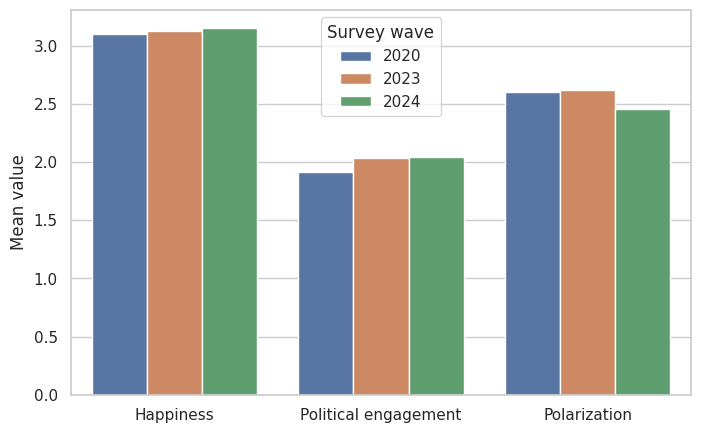

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------
# mismo estilo que el otro gráfico
sns.set_theme(style="whitegrid")

# ---------------------------------
# Variables
vars_plot = [
    "felicidad",
    "interes_politica",
    "polarizacion_continua"
]

labels_map = {
    "felicidad": "Happiness",
    "interes_politica": "Political engagement",
    "polarizacion_continua": "Polarization"
}

# ---------------------------------
# Promedios por wave
means_by_wave = (
    df_long
    .groupby("wave")[vars_plot]
    .mean()
    .reset_index()
)

# formato largo
df_plot = means_by_wave.melt(
    id_vars="wave",
    value_vars=vars_plot,
    var_name="variable",
    value_name="value"
)

df_plot["variable"] = (
    df_plot["variable"]
    .map(labels_map)
)

# ---------------------------------
# usar la misma paleta default agradable
palette = sns.color_palette("deep")

# ---------------------------------
# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_plot,
    x="variable",
    y="value",
    hue="wave",
    palette=palette,
    errorbar=None
)

plt.xlabel("")
plt.ylabel("Mean value")

plt.legend(title="Survey wave")

plt.show()

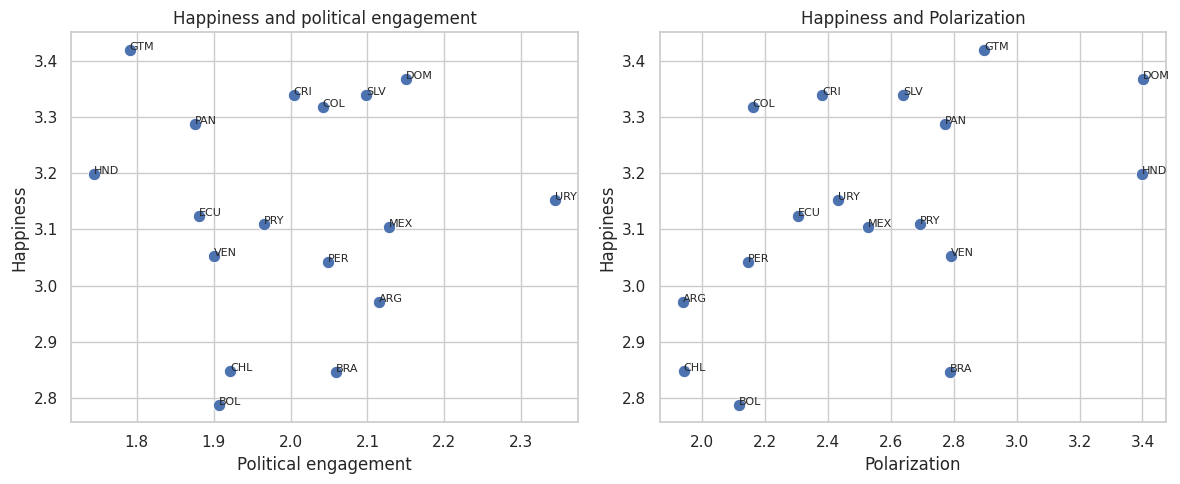

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# Mapping country → ISO3
map_iso3 = {
    32: "ARG", 68: "BOL", 76: "BRA", 152: "CHL", 170: "COL",
    188: "CRI", 192: "CUB", 214: "DOM", 218: "ECU", 222: "SLV",
    320: "GTM", 340: "HND", 484: "MEX", 558: "NIC", 591: "PAN",
    600: "PRY", 604: "PER", 858: "URY", 862: "VEN"
}

# ---------------------------
# Variables
vars_plot = [
    "felicidad",
    "interes_politica",
    "polarizacion_continua"
]

# ---------------------------
# Clean copy
df = df_long.copy()
df["wave"] = pd.to_numeric(df["wave"], errors="coerce")

# ---------------------------
# Country-wave averages
df_country = (
    df
    .groupby(["pais", "wave"], as_index=False)[vars_plot]
    .mean()
)

# Add ISO3 labels
df_country["iso3"] = df_country["pais"].map(map_iso3)

# ---------------------------
# Keep only countries with data in ALL waves
n_waves = df_country["wave"].nunique()

valid_countries = (
    df_country
    .groupby("pais")["wave"]
    .nunique()
)

valid_countries = valid_countries[
    valid_countries == n_waves
].index

df_country = df_country[
    df_country["pais"].isin(valid_countries)
]

# ---------------------------
# Collapse across all waves
df_country_mean = (
    df_country
    .groupby(["pais", "iso3"], as_index=False)[vars_plot]
    .mean()
)

# ---------------------------
# Plot
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------------------------------
# Happiness vs Political engagement
ax1 = axes[0]

sns.scatterplot(
    data=df_country_mean,
    x="interes_politica",
    y="felicidad",
    ax=ax1,
    s=80
)

for _, row in df_country_mean.iterrows():
    ax1.text(
        row["interes_politica"],
        row["felicidad"],
        row["iso3"],
        fontsize=8
    )

ax1.set_title("Happiness and political engagement")
ax1.set_xlabel("Political engagement")
ax1.set_ylabel("Happiness")

# ---------------------------------
# Happiness vs Polarization
ax2 = axes[1]

sns.scatterplot(
    data=df_country_mean,
    x="polarizacion_continua",
    y="felicidad",
    ax=ax2,
    s=80
)

for _, row in df_country_mean.iterrows():
    ax2.text(
        row["polarizacion_continua"],
        row["felicidad"],
        row["iso3"],
        fontsize=8
    )

ax2.set_title("Happiness and Polarization")
ax2.set_xlabel("Polarization")
ax2.set_ylabel("Happiness")

plt.tight_layout()
plt.show()

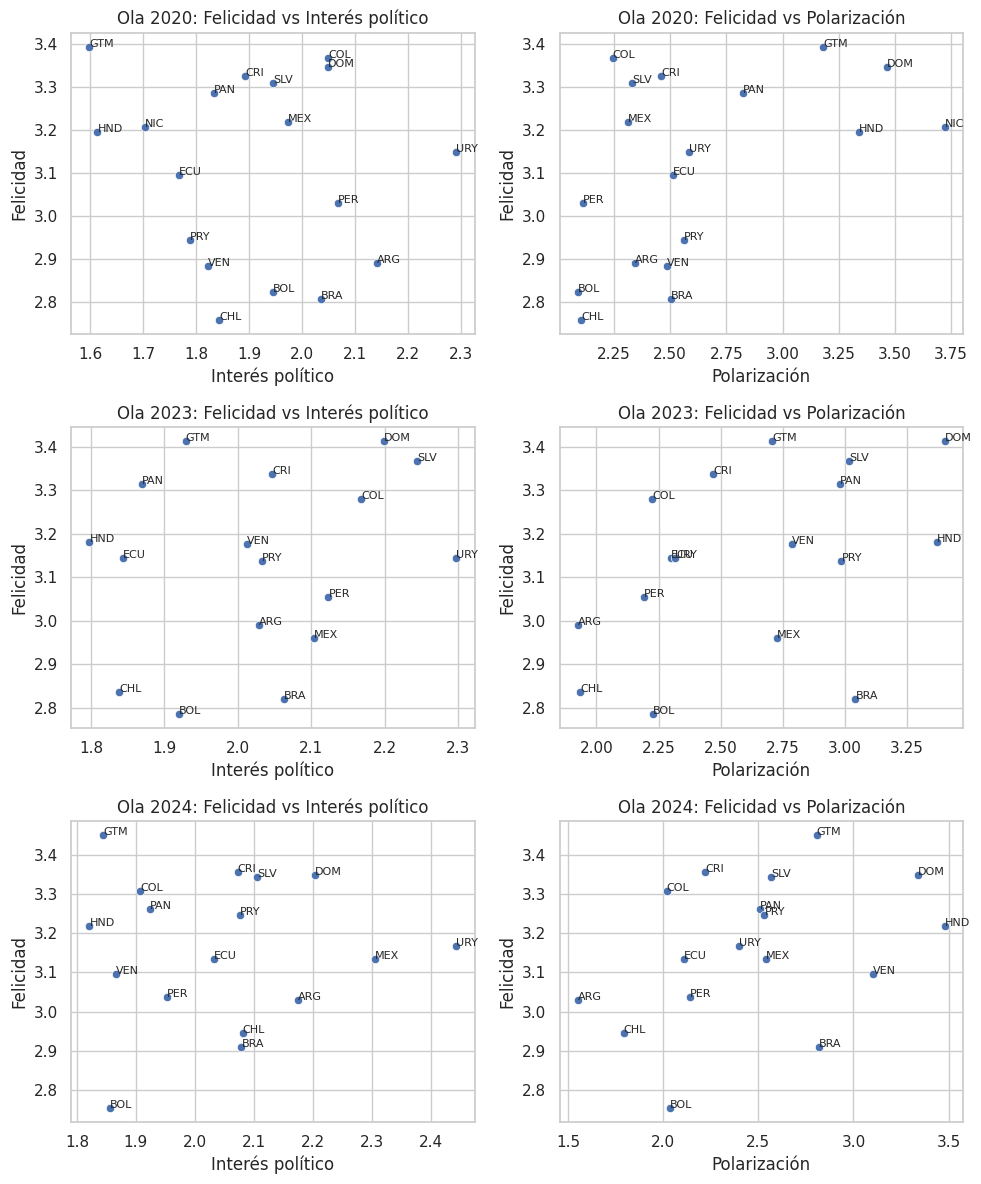

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
#  Mapping idenpa → ISO3
map_iso3 = {
    32: "ARG", 68: "BOL", 76: "BRA", 152: "CHL", 170: "COL",
    188: "CRI", 192: "CUB", 214: "DOM", 218: "ECU", 222: "SLV",
    320: "GTM", 340: "HND", 484: "MEX", 558: "NIC", 591: "PAN",
    600: "PRY", 604: "PER", 858: "URY", 862: "VEN"
}

# ---------------------------
# Limpieza mínima
vars_plot = ["felicidad", "interes_politica", "polarizacion_continua"]

df = df_long.copy()
df["wave"] = pd.to_numeric(df["wave"], errors="coerce")

# ---------------------------
# 3) Colapso país–ola
df_country = (
    df
    .groupby(["pais", "wave"], as_index=False)[vars_plot]
    .mean()
)

# agregar ISO3
df_country["iso3"] = df_country["pais"].map(map_iso3)

# ---------------------------
# Gráficos (6 en total)
sns.set(style="whitegrid")

waves = sorted(df_country["wave"].dropna().unique())

fig, axes = plt.subplots(len(waves), 2, figsize=(10, 4*len(waves)))

if len(waves) == 1:
    axes = [axes]  # asegurar iterabilidad

for i, w in enumerate(waves):
    sub = df_country[df_country["wave"] == w]

    # Scatter 1: felicidad vs interés político
    ax1 = axes[i][0]
    sns.scatterplot(data=sub, x="interes_politica", y="felicidad", ax=ax1)

    for _, row in sub.iterrows():
        ax1.text(row["interes_politica"], row["felicidad"], row["iso3"], fontsize=8)

    ax1.set_title(f"Ola {int(w)}: Felicidad vs Interés político")
    ax1.set_xlabel("Interés político")
    ax1.set_ylabel("Felicidad")

    # Scatter 2: felicidad vs polarización
    ax2 = axes[i][1]
    sns.scatterplot(data=sub, x="polarizacion_continua", y="felicidad", ax=ax2)

    for _, row in sub.iterrows():
        ax2.text(row["polarizacion_continua"], row["felicidad"], row["iso3"], fontsize=8)

    ax2.set_title(f"Ola {int(w)}: Felicidad vs Polarización")
    ax2.set_xlabel("Polarización")
    ax2.set_ylabel("Felicidad")

plt.tight_layout()
plt.show()

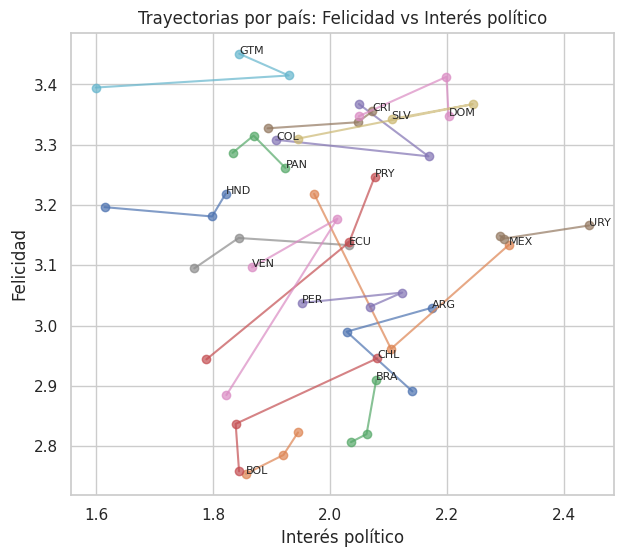

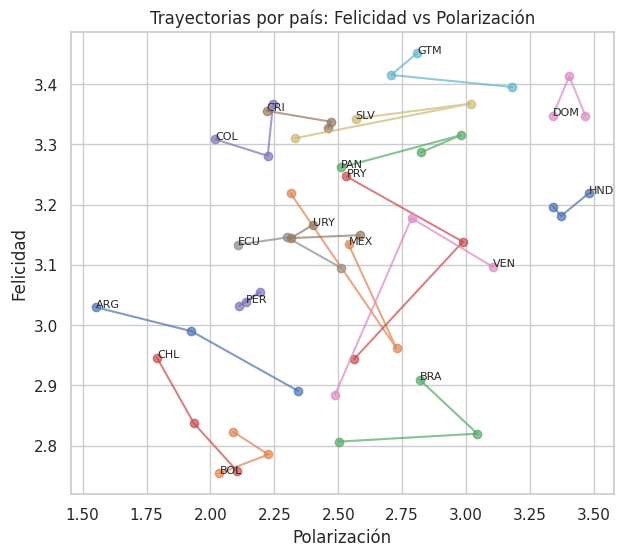

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# Preparación (igual que antes)
map_iso3 = {
    32: "ARG", 68: "BOL", 76: "BRA", 152: "CHL", 170: "COL",
    188: "CRI", 192: "CUB", 214: "DOM", 218: "ECU", 222: "SLV",
    320: "GTM", 340: "HND", 484: "MEX", 558: "NIC", 591: "PAN",
    600: "PRY", 604: "PER", 858: "URY", 862: "VEN"
}

vars_plot = ["felicidad", "interes_politica", "polarizacion_continua"]

df = df_long.copy()
df["wave"] = pd.to_numeric(df["wave"], errors="coerce")

df_country = (
    df.groupby(["pais", "wave"], as_index=False)[vars_plot]
    .mean()
)

df_country["iso3"] = df_country["pais"].map(map_iso3)

sns.set(style="whitegrid")

# ---------------------------
# 1) Felicidad vs Interés político (trayectorias)

valid_paises = df_country.groupby("pais")["wave"].nunique()
valid_paises = valid_paises[valid_paises == 3].index

df_country_filt = df_country[df_country["pais"].isin(valid_paises)]

plt.figure(figsize=(7,6))

for pais, sub in df_country_filt.groupby("pais"):
    sub = sub.sort_values("wave")

    plt.plot(
        sub["interes_politica"],
        sub["felicidad"],
        marker="o",
        alpha=0.7
    )

    # etiqueta solo en el último punto (2024)
    last = sub.iloc[-1]
    plt.text(last["interes_politica"], last["felicidad"], last["iso3"], fontsize=8)

plt.xlabel("Interés político")
plt.ylabel("Felicidad")
plt.title("Trayectorias por país: Felicidad vs Interés político")

plt.show()


# ---------------------------
# 2) Felicidad vs Polarización (trayectorias)

plt.figure(figsize=(7,6))

for pais, sub in df_country_filt.groupby("pais"):
    sub = sub.sort_values("wave")

    plt.plot(
        sub["polarizacion_continua"],
        sub["felicidad"],
        marker="o",
        alpha=0.7
    )

    last = sub.iloc[-1]
    plt.text(last["polarizacion_continua"], last["felicidad"], last["iso3"], fontsize=8)

plt.xlabel("Polarización")
plt.ylabel("Felicidad")
plt.title("Trayectorias por país: Felicidad vs Polarización")

plt.show()

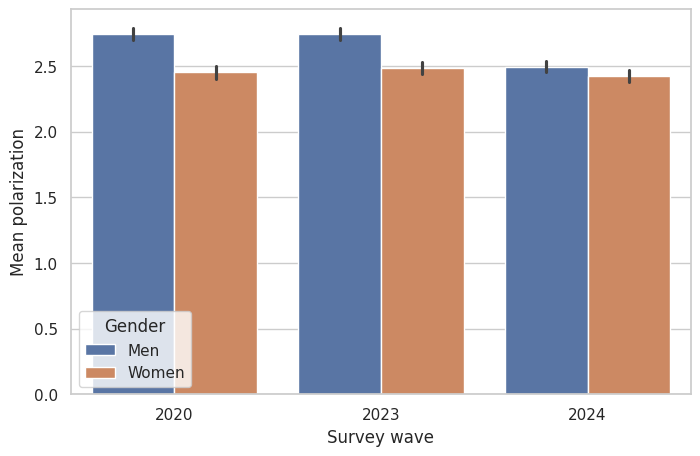

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
gender_map = {
    1: "Men",
    0: "Women"
}

df_long["gender_label"] = df_long["genero"].map(gender_map)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_long,
    x="wave",
    y="polarizacion_continua",
    hue="gender_label",
    errorbar=("ci",95)
)

#plt.title("Polarization by gender")
plt.xlabel("Survey wave")
plt.ylabel("Mean polarization")
plt.legend(title="Gender")

plt.show()

/tmp/ipykernel_10016/1657609455.py:63: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(


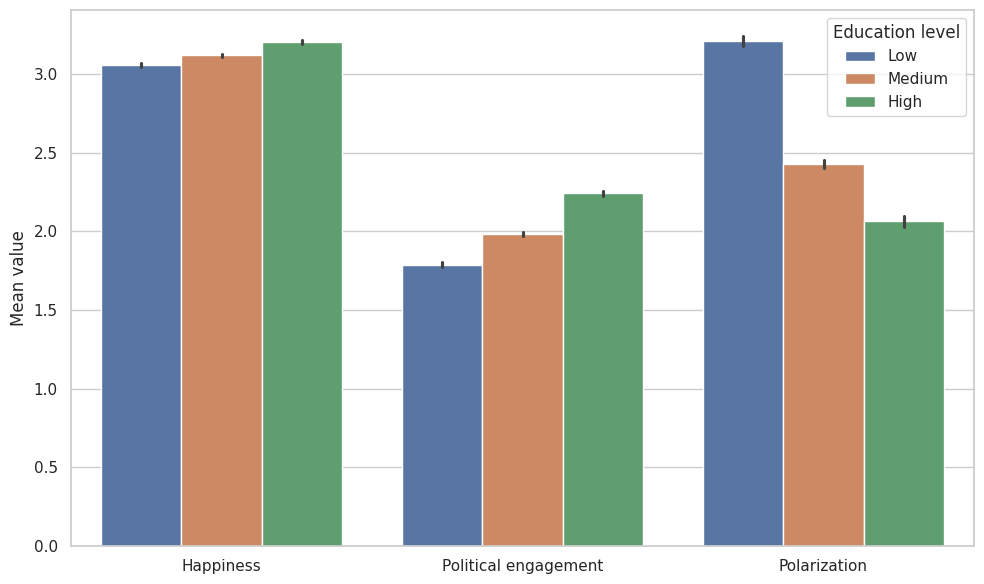

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------
# estilo
sns.set_theme(style="whitegrid")

# ---------------------------------
# Crear niveles educativos ordenados
def education_group(x):
    if pd.isna(x):
        return np.nan
    elif x <= 6:
        return "Low"
    elif x <= 12:
        return "Medium"
    else:
        return "High"

df_plot = df_long.copy()

df_plot["education_level"] = (
    df_plot["educacion"]
    .apply(education_group)
)

# asegurar orden
education_order = ["Low", "Medium", "High"]

# ---------------------------------
# Variables
vars_plot = [
    "felicidad",
    "interes_politica",
    "polarizacion_continua"
]

labels_map = {
    "felicidad": "Happiness",
    "interes_politica": "Political engagement",
    "polarizacion_continua": "Polarization"
}

# ---------------------------------
# Formato largo
df_melt = df_plot.melt(
    id_vars="education_level",
    value_vars=vars_plot,
    var_name="variable",
    value_name="value"
)

df_melt["variable"] = (
    df_melt["variable"]
    .map(labels_map)
)

# ---------------------------------
# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_melt,
    x="variable",
    y="value",
    hue="education_level",
    hue_order=education_order,
    palette=sns.color_palette("deep"),
    errorbar=("ci",95)
)

#plt.title("Political attitudes by education level")
plt.xlabel("")
plt.ylabel("Mean value")

plt.legend(title="Education level")

plt.tight_layout()
plt.show()

# Estandarización

In [42]:
vars_z = [
    "felicidad", "interes_politica", "eficacia_voto", "representacion",
    "polarizacion_continua", "identificacion_partidaria", "polarizacion_economia",
    "democratico", "nodemocratico",
    "econ_pais", "econ_personal",
    "edad2", "confianza", "edad", "educacion"]

for v in vars_z:
    df_long[f"{v}_z"] = np.nan

for wave in df_long["wave"].unique():
    mask = df_long["wave"] == wave
    for v in vars_z:
        if v in df_long.columns:
            s = df_long.loc[mask, v].astype(float)
            mean = s.mean(skipna=True)
            sd = s.std(skipna=True)
            df_long.loc[mask, f"{v}_z"] = (s - mean) / sd if sd not in [0, None] else np.nan

In [43]:
import statsmodels.formula.api as smf

# datos limpios
cols = ["felicidad_z", "polarizacion_continua_z", "interes_politica_z", "pais", "wave"]
df_reg = df_long[cols].dropna()

# modelo con interacciones
model_int = smf.ols(
    "felicidad_z ~ polarizacion_continua_z*C(wave) + interes_politica_z*C(wave) + C(pais)",
    data=df_reg
).fit(cov_type="cluster", cov_kwds={"groups": df_reg["pais"]})

# extraer coeficientes por ola
waves = sorted(df_reg["wave"].unique())

rows = []

base_pol = model_int.params["polarizacion_continua_z"]
base_eng = model_int.params["interes_politica_z"]

for w in waves:
    # nombres de coeficientes de interacción
    pol_term = f"polarizacion_continua_z:C(wave)[T.{w}]"
    eng_term = f"interes_politica_z:C(wave)[T.{w}]"

    pol = base_pol + (model_int.params.get(pol_term, 0))
    eng = base_eng + (model_int.params.get(eng_term, 0))

    ci = model_int.conf_int()

    # aproximación simple de CI (lineal, suficiente para visual)
    pol_low = ci.loc["polarizacion_continua_z", 0] + (ci.loc[pol_term, 0] if pol_term in ci.index else 0)
    pol_high = ci.loc["polarizacion_continua_z", 1] + (ci.loc[pol_term, 1] if pol_term in ci.index else 0)

    eng_low = ci.loc["interes_politica_z", 0] + (ci.loc[eng_term, 0] if eng_term in ci.index else 0)
    eng_high = ci.loc["interes_politica_z", 1] + (ci.loc[eng_term, 1] if eng_term in ci.index else 0)

    rows.append({"wave": w, "variable": "Polarización", "coef": pol, "low": pol_low, "high": pol_high})
    rows.append({"wave": w, "variable": "Engagement", "coef": eng, "low": eng_low, "high": eng_high})

df_coef = pd.DataFrame(rows)

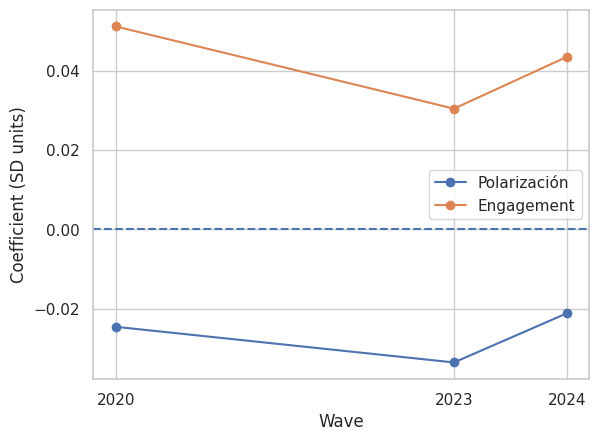

In [44]:
df_wide = df_coef.pivot(index="wave", columns="variable", values="coef").reset_index()

for var in ["Polarización", "Engagement"]:
    sub = df_coef[df_coef["variable"] == var]
    plt.plot(sub["wave"], sub["coef"], marker='o', label=var)

plt.axhline(0, linestyle='--')
plt.xlabel("Wave")
plt.ylabel("Coefficient (SD units)")
#plt.title("Associations with happiness by wave")
plt.legend()

# fix eje X
plt.xticks(sorted(df_coef["wave"].unique()))

plt.show()

# Cross-lagged

In [ ]:
############################ 1. BASELINE ############################

import statsmodels.formula.api as smf

vars_modelo = ["felicidad_z", "protestas", "polarizacion_continua_z", "pais"]

vars_all = [
    "felicidad_z","interes_politica_z","polarizacion_continua_z", "polarizacion_economia_z",
    "econ_pais_z","econ_personal_z","confianza_z", "identificacion_partidaria_z",
    "edad","educacion","pais","wave", "protestas", "ciudad"
]

df_clean = df_long[vars_all].dropna()

baseline = smf.ols(
    """felicidad_z ~ interes_politica_z + polarizacion_continua_z""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais"]}
)

print(baseline.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     5.946
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0110
Time:                        19:31:24   Log-Likelihood:                -70719.
No. Observations:               50140   AIC:                         1.414e+05
Df Residuals:                   50137   BIC:                         1.415e+05
Df Model:                           2                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [ ]:
############################ 2. Con Controles ############################

import statsmodels.formula.api as smf

controles = smf.ols(
    """felicidad_z ~ interes_politica_z + polarizacion_continua_z
             + econ_pais_z + econ_personal_z
             + confianza_z + edad + educacion""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais"]}
)

print(controles.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     19.96
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.93e-07
Time:                        19:31:24   Log-Likelihood:                -70157.
No. Observations:               50140   AIC:                         1.403e+05
Df Residuals:                   50132   BIC:                         1.404e+05
Df Model:                           7                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [ ]:
############################ 3. FE País y Año ############################

import statsmodels.formula.api as smf

fe = smf.ols(
    """felicidad_z ~ interes_politica_z + polarizacion_continua_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais"]}
)


print(fe.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     179.5
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           7.03e-15
Time:                        19:31:25   Log-Likelihood:                -68923.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50114   BIC:                         1.381e+05
Df Model:                          25                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 25, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [ ]:
############################ 4. Interacción Simple ############################

import statsmodels.formula.api as smf

interaccion = smf.ols(
    """felicidad_z ~ interes_politica_z * polarizacion_continua_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais"]})

print(interaccion.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     161.3
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.15e-14
Time:                        19:31:25   Log-Likelihood:                -68923.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50113   BIC:                         1.381e+05
Df Model:                          26                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 9
  warnings.warn('covariance of constraints does not have full '


In [ ]:
############################ 5. Descomposición ############################

import statsmodels.formula.api as smf

df_clean["polar_country_wave"] = (
    df_clean
    .groupby(["pais","wave"])["polarizacion_continua_z"]
    .transform("mean")
)

df_clean["polar_within"] = (
    df_clean["polarizacion_continua_z"] - df_clean["polar_country_wave"]
)

desc = smf.ols(
    """felicidad_z ~ polar_within + polar_country_wave
             + interes_politica_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais"]})

print(desc.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     351.4
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.66e-17
Time:                        19:31:26   Log-Likelihood:                -68922.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50113   BIC:                         1.381e+05
Df Model:                          26                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.2317      0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 9
  warnings.warn('covariance of constraints does not have full '


In [ ]:
############################ 6. Interacción Multinivel ############################

import statsmodels.formula.api as smf

multinivel = smf.ols(
    """felicidad_z ~ polar_within + polar_country_wave
             + interes_politica_z
             + interes_politica_z:polar_within
             + interes_politica_z:polar_country_wave
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais"]})

print(multinivel.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     404.5
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.67e-18
Time:                        19:31:26   Log-Likelihood:                -68917.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50111   BIC:                         1.381e+05
Df Model:                          28                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 11
  warnings.warn('covariance of constraints does not have full '


# Tabla LaTex

In [ ]:
from statsmodels.iolib.summary2 import summary_col
import pandas as pd

# -------------------------
# Modelos
# -------------------------
models = [baseline, controles, fe, interaccion, desc, multinivel]
model_names = ["(1)", "(2)", "(3)", "(4)", "(5)", "(6)"]

# -------------------------
# Renombrar variables
# -------------------------
rename_dict = {
    "interes_politica_z": "Political engagement",
    "polarizacion_continua_z": "Polarization",
    "polar_within": "Polarization (within)",
    "polar_country_wave": "Polarization (country-wave mean)",
    "interes_politica_z:polarizacion_continua_z": "Engagement × Polarization",
    "interes_politica_z:polar_within": "Engagement × Polarization (within)",
    "interes_politica_z:polar_country_wave": "Engagement × Polarization (context)"
}

# -------------------------
# Indicadores FE
# -------------------------
def has_fe(x, term):
    return "Yes" if any(term in str(p) for p in x.params.index) else "No"

info_dict = {
    "N": lambda x: f"{int(x.nobs)}",
    "R-squared": lambda x: f"{getattr(x, 'rsquared', float('nan')):.3f}",
    "Country FE": lambda x: has_fe(x, "C(pais)"),
    "Wave FE": lambda x: has_fe(x, "C(wave)")
}

# -------------------------
# Orden de variables
# -------------------------
order = [
    "interes_politica_z",
    "polarizacion_continua_z",
    "interes_politica_z:polarizacion_continua_z",
    "polar_within",
    "polar_country_wave",
    "interes_politica_z:polar_within",
    "interes_politica_z:polar_country_wave"
]

# -------------------------
# Crear tabla base
# -------------------------
table = summary_col(
    models,
    stars=True,
    float_format='%0.3f',
    model_names=model_names,
    info_dict=info_dict,
    regressor_order=order
)

df = table.tables[0].copy()

# Renombrar variables
df.index = [rename_dict.get(i, i) for i in df.index]

# Eliminar FE dummies
df = df[~df.index.str.contains("C\\(pais\\)|C\\(wave\\)", regex=True)]
df = df.loc[df.index != ""]

# -------------------------
# Manejo de duplicados
# -------------------------
df_reset = df.reset_index()
df_reset.columns = ["var"] + list(df.columns)

# Paneles
panel_A_vars = [
    "Political engagement",
    "Polarization",
    "Engagement × Polarization"
]

panel_B_vars = [
    "Polarization (within)",
    "Polarization (country-wave mean)",
    "Engagement × Polarization (within)",
    "Engagement × Polarization (context)"
]

def get_block(var_list):
    return df_reset[df_reset["var"].isin(var_list)]

panel_A = get_block(panel_A_vars)
panel_B = get_block(panel_B_vars)

used_vars = panel_A_vars + panel_B_vars
rest = df_reset[~df_reset["var"].isin(used_vars)]

def make_header(title):
    return pd.DataFrame([[title] + [""] * (df.shape[1])], columns=df_reset.columns)

# Construir tabla final
df_final = pd.concat([
    make_header("Panel A: Polarization (total)"),
    panel_A,
    make_header("Panel B: Polarization decomposition"),
    panel_B,
    rest
], ignore_index=True)

df_final = df_final.set_index("var")

# -------------------------
# FIX FINAL: limpiar y ordenar estadísticas
# -------------------------

# eliminar duplicados de R-squared
df_final = df_final[~((df_final.index == "R-squared") & (df_final.index.duplicated()))]

# orden estándar
stats_order = ["N", "R-squared", "Country FE", "Wave FE"]

coef_part = df_final.loc[~df_final.index.isin(stats_order)]
stats_part = df_final.loc[df_final.index.isin(stats_order)]

# reordenar stats
stats_part = stats_part.reindex(stats_order)

# unir
df_final = pd.concat([coef_part, stats_part])

# -------------------------
# Reemplazar tabla
# -------------------------
table.tables[0] = df_final

# -------------------------
# Exportar a LaTeX
# -------------------------
latex_table = table.as_latex()

latex_table = latex_table.replace(
    "Standard errors in parentheses.",
    "Clustered standard errors (country level) in parentheses."
)

with open("tabla_resultados.tex", "w") as f:
    f.write(latex_table)

print(latex_table)

\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllll}
\hline
                                    & (1)      & (2)       & (3)       & (4)       & (5)       & (6)        \\
\hline
Panel A: Polarization (total)       &          &           &           &           &           &            \\
Political engagement                & 0.035*** & 0.017*    & 0.018***  & 0.018***  & 0.018***  & 0.018***   \\
Polarization                        & -0.007   & 0.016*    & -0.000    & -0.000    &           &            \\
Engagement × Polarization           &          &           &           & 0.001     &           &            \\
Panel B: Polarization decomposition &          &           &           &           &           &            \\
Polarization (within)               &          &           &           &           & -0.001    & -0.001     \\
Polarization (country-wave mean)    &          &           &           &           & 0.052     & 0.054      \\
Engagement × Polarizatio

## Gráfico

In [ ]:
b1 = multinivel.params["interes_politica_z"]
b4 = multinivel.params["interes_politica_z:polar_country_wave"]

import numpy as np

x = np.linspace(
    df_clean["polar_country_wave"].min(),
    df_clean["polar_country_wave"].max(),
    100
)

marginal_effect = b1 + b4 * x

cov = multinivel.cov_params()

var_b1 = cov.loc["interes_politica_z", "interes_politica_z"]
var_b4 = cov.loc["interes_politica_z:polar_country_wave", "interes_politica_z:polar_country_wave"]
cov_b1b4 = cov.loc["interes_politica_z", "interes_politica_z:polar_country_wave"]

se = np.sqrt(var_b1 + (x**2)*var_b4 + 2*x*cov_b1b4)

upper = marginal_effect + 1.96 * se
lower = marginal_effect - 1.96 * se

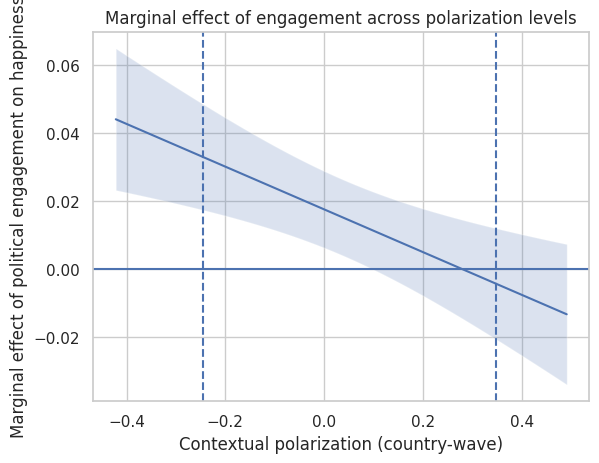

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(x, marginal_effect)
plt.fill_between(x, lower, upper, alpha=0.2)

plt.axhline(0)

p10 = np.percentile(df_clean["polar_country_wave"], 10)
p90 = np.percentile(df_clean["polar_country_wave"], 90)

plt.axvline(p10, linestyle="--")
plt.axvline(p90, linestyle="--")

plt.xlabel("Contextual polarization (country-wave)")
plt.ylabel("Marginal effect of political engagement on happiness")

plt.title("Marginal effect of engagement across polarization levels")

plt.show()

# Robustez

## Robustez de errores estándar

In [ ]:
## Robustez de errores estándar
# Reestimo con clusterización por país y por pais_wave el coeficiente de -0.047* debería mantenerse

df_clean["pais_wave"] = (
    df_clean["pais"].astype(str) + "_" + df_clean["wave"].astype(str)
)

########### Modelo 3 ##############

multinivel_fe = smf.ols(
    """felicidad_z ~ interes_politica_z + polarizacion_continua_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais_wave"]}
)


print(multinivel_fe.summary())

print('')
print('-----------------------')
print('Modelo 3')

print("Cluster país:")
print(fe.params["interes_politica_z"],
      fe.bse["interes_politica_z"])

print("\nCluster país-wave:")
print(multinivel_fe.params["interes_politica_z"],
      multinivel_fe.bse["interes_politica_z"])

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     245.3
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           8.59e-45
Time:                        19:31:29   Log-Likelihood:                -68923.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50114   BIC:                         1.381e+05
Df Model:                          25                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [ ]:
#################### Modelo 4 ################33


multinivel_interaccion = smf.ols(
    """felicidad_z ~ interes_politica_z * polarizacion_continua_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais_wave"]})

print(multinivel_interaccion.summary())



print('')
print('-----------------------')
print('Modelo 4')

print("Cluster país:")
print(interaccion.params["interes_politica_z"],
      interaccion.bse["interes_politica_z"])

print("\nCluster país-wave:")
print(multinivel_interaccion.params["interes_politica_z"],
      multinivel_interaccion.bse["interes_politica_z"])

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     264.8
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           8.12e-46
Time:                        19:31:29   Log-Likelihood:                -68923.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50113   BIC:                         1.381e+05
Df Model:                          26                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [ ]:
########### Modelo 5 #############

multinivel_desc = smf.ols(
    """felicidad_z ~ polar_within + polar_country_wave
             + interes_politica_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais_wave"]})

print(multinivel_desc.summary())



print('')
print('-----------------------')
print('Modelo 5')

print("Cluster país:")
print(desc.params["interes_politica_z"],
      desc.bse["interes_politica_z"])

print("\nCluster país-wave:")
print(multinivel_desc.params["interes_politica_z"],
      multinivel_desc.bse["interes_politica_z"])

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     1253.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           6.16e-63
Time:                        19:31:30   Log-Likelihood:                -68922.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50113   BIC:                         1.381e+05
Df Model:                          26                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.2317      0

In [ ]:
########### Modelo 6 ##############


multinivel_cw = smf.ols(
    """felicidad_z ~ polar_within + polar_country_wave
             + interes_politica_z
             + interes_politica_z:polar_within
             + interes_politica_z:polar_country_wave
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais_wave"]}
)

print(multinivel_cw.summary())

print('')
print('-----------------------')
print('Modelo 6')

print("Cluster país:")
print(multinivel.params["interes_politica_z:polar_country_wave"],
      multinivel.bse["interes_politica_z:polar_country_wave"])

print("\nCluster país-wave:")
print(multinivel_cw.params["interes_politica_z:polar_country_wave"],
      multinivel_cw.bse["interes_politica_z:polar_country_wave"])

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     5445.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.55e-79
Time:                        19:31:31   Log-Likelihood:                -68917.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50111   BIC:                         1.381e+05
Df Model:                          28                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## Robustez de outliers por país

In [ ]:
# Saco de la muestra los países extremos en polarización

country_polar = (
    df_clean.groupby("pais")["polar_country_wave"]
    .mean()
)

p5 = country_polar.quantile(0.05)
p95 = country_polar.quantile(0.95)

outlier_countries = country_polar[
    (country_polar < p5) | (country_polar > p95)
].index

df_no_outliers = df_clean[
    ~df_clean["pais"].isin(outlier_countries)
]

multinivel_no_out = smf.ols(
    """felicidad_z ~ polar_within + polar_country_wave
             + interes_politica_z
             + interes_politica_z:polar_within
             + interes_politica_z:polar_country_wave
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_no_outliers
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_no_outliers["pais_wave"]}
)

print(multinivel_no_out.summary())

print('----------------')
print('Comparación sin países outlier')

print("Baseline:")
print(multinivel.params["interes_politica_z:polar_country_wave"],
      multinivel.bse["interes_politica_z:polar_country_wave"])

print("\nSin outliers:")
print(multinivel_no_out.params["interes_politica_z:polar_country_wave"],
      multinivel_no_out.bse["interes_politica_z:polar_country_wave"])

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     339.1
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.22e-45
Time:                        19:31:31   Log-Likelihood:                -64658.
No. Observations:               46975   AIC:                         1.294e+05
Df Residuals:                   46948   BIC:                         1.296e+05
Df Model:                          26                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

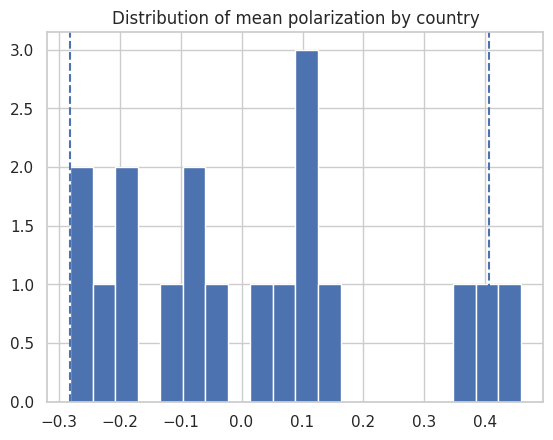

In [ ]:
import matplotlib.pyplot as plt

plt.hist(country_polar, bins=20)
plt.axvline(p5, linestyle="--")
plt.axvline(p95, linestyle="--")
plt.title("Distribution of mean polarization by country")
plt.show()

In [ ]:
country_map = {
    32: "Argentina",
    68: "Bolivia",
    76: "Brazil",
    152: "Chile",
    170: "Colombia",
    188: "Costa Rica",
    192: "Cuba",
    214: "Dominican Republic",
    218: "Ecuador",
    222: "El Salvador",
    320: "Guatemala",
    340: "Honduras",
    484: "Mexico",
    558: "Nicaragua",
    591: "Panama",
    600: "Paraguay",
    604: "Peru",
    858: "Uruguay",
    862: "Venezuela"
}

outliers = country_polar[(country_polar < p5) | (country_polar > p95)]

outliers.index.map(country_map)

Index(['Chile', 'Nicaragua'], dtype='object', name='pais')

## Alternativas de polarización

In [ ]:
df_clean["pid_country_wave"] = (
    df_clean
    .groupby(["pais","wave"])["identificacion_partidaria_z"]
    .transform("mean")
)

df_clean["pid_within"] = (
    df_clean["identificacion_partidaria_z"] - df_clean["pid_country_wave"]
)

In [ ]:
pid_model = smf.ols(
    """felicidad_z ~ pid_within + pid_country_wave
             + interes_politica_z
             + interes_politica_z:pid_within
             + interes_politica_z:pid_country_wave
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais_wave"]}
)

print(pid_model.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     211.9
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.01e-43
Time:                        19:31:32   Log-Likelihood:                -68916.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50111   BIC:                         1.381e+05
Df Model:                          28                                         
Covariance Type:              cluster                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [ ]:
df_clean["polar_econ_cw"] = (
    df_clean
    .groupby(["pais","wave"])["polarizacion_economia_z"]
    .transform("mean")
)

df_clean["polar_econ_within"] = (
    df_clean["polarizacion_economia_z"] - df_clean["polar_econ_cw"]
)

In [ ]:
econpol_model = smf.ols(
    """felicidad_z ~ polar_econ_cw
             + interes_politica_z
             + interes_politica_z:polar_econ_cw
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais_wave"]}
)

print(econpol_model.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     510.0
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           5.09e-53
Time:                        19:31:33   Log-Likelihood:                -68912.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50113   BIC:                         1.381e+05
Df Model:                          26                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

## Contexto de ciudad

In [ ]:
############################ 5. Descomposición por Ciudad ############################

import statsmodels.formula.api as smf

df_clean["polar_city_wave"] = (
    df_clean
    .groupby(["ciudad","wave"])["polarizacion_continua_z"]
    .transform("mean")
)

df_clean["polar_within"] = (
    df_clean["polarizacion_continua_z"] - df_clean["polar_city_wave"]
)

multinivel = smf.ols(
    """felicidad_z ~ polar_within + polar_city_wave
             + interes_politica_z
             + interes_politica_z:polar_within
             + interes_politica_z:polar_city_wave
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais"]})

print(multinivel.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     229.6
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.17e-16
Time:                        19:37:54   Log-Likelihood:                -68916.
No. Observations:               50140   AIC:                         1.379e+05
Df Residuals:                   50111   BIC:                         1.381e+05
Df Model:                          28                                         
Covariance Type:              cluster                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 11
  warnings.warn('covariance of constraints does not have full '
